# Low Review Score Prediction

This notebook develops a machine learning model for identifying delivered orders with a high risk of receiving a low customer review score.

A review is classified as low when the score is equal to 1 or 2.

The main goals are:
- to build an interpretable binary classification model;
- to compare linear and tree-based approaches;
- to evaluate model quality using metrics suitable for an imbalanced target;
- to select a decision threshold based on business priorities;
- to identify the factors associated with customer dissatisfaction.

In [62]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from etl.config import get_engine

engine = get_engine()

pd.set_option("display.max_columns", 100)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.3f}",
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

RANDOM_STATE = 42

pd.read_sql(
    "SELECT current_database() AS database_name;",
    engine,
)

,database_name
0,olist_analytics


## 1. Problem Definition and Data Preparation

### Target Definition

The target variable is `is_low_review`:

- `1` — the delivered order received a review score of 1 or 2;
- `0` — the delivered order received a review score from 3 to 5.

The model is intended as a post-delivery risk model. Therefore, actual delivery performance variables may be used as predictors.

The analysis includes only delivered orders with an available review score.

In [6]:
query = """
SELECT
    m.order_id,
    m.average_review_score AS review_score,
    m.order_items_value AS order_value,
    m.products_value,
    m.freight_value,
    m.items_count,
    m.payment_value,
    m.delivery_time_days,
    m.delivery_delay_days,
    m.is_delayed,
    m.customer_state
FROM analytics.order_metrics AS m
WHERE m.order_status = 'delivered'
  AND m.average_review_score IS NOT NULL;
"""

model_data = pd.read_sql(query, engine)

model_data.head()

,order_id,review_score,order_value,products_value,freight_value,items_count,payment_value,delivery_time_days,delivery_delay_days,is_delayed,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,5.000,72.190,58.900,13.290,1,72.190,7.614,-8.011,False,RJ
1,00018f77f2f0320c557190d7a144bdd3,4.000,259.830,239.900,19.930,1,259.830,16.216,-2.330,False,SP
2,000229ec398224ef6ca0657da4fc703e,5.000,216.870,199.000,17.870,1,216.870,7.948,-13.445,False,MG
3,00024acbcdf0a6daa1e931b038114c75,4.000,25.780,12.990,12.790,1,25.780,6.147,-5.436,False,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.000,218.040,199.900,18.140,1,218.040,25.114,-15.304,False,SP


In [7]:
model_data.shape

(95832, 11)

In [8]:
model_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95832 entries, 0 to 95831
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             95832 non-null  object 
 1   review_score         95832 non-null  float64
 2   order_value          95832 non-null  float64
 3   products_value       95832 non-null  float64
 4   freight_value        95832 non-null  float64
 5   items_count          95832 non-null  int64  
 6   payment_value        95831 non-null  float64
 7   delivery_time_days   95824 non-null  float64
 8   delivery_delay_days  95824 non-null  float64
 9   is_delayed           95824 non-null  object 
 10  customer_state       95832 non-null  object 
dtypes: float64(7), int64(1), object(3)
memory usage: 8.0+ MB


In [9]:
model_data.isna().sum().sort_values(
    ascending=False
)

delivery_time_days     8
delivery_delay_days    8
is_delayed             8
payment_value          1
order_id               0
review_score           0
order_value            0
products_value         0
freight_value          0
items_count            0
customer_state         0
dtype: int64

In [11]:
model_data["is_low_review"] = (
    model_data["review_score"] <= 2
).astype(int)

model_data = model_data.drop(
    columns="review_score"
)

In [12]:
target_distribution = (
    model_data["is_low_review"]
    .value_counts()
    .rename_axis("is_low_review")
    .reset_index(name="orders_count")
)

target_distribution["review_group"] = (
    target_distribution["is_low_review"]
    .map(
        {
            0: "Score 3–5",
            1: "Score 1–2",
        }
    )
)

target_distribution["orders_share_percent"] = (
    target_distribution["orders_count"]
    / target_distribution["orders_count"].sum()
    * 100
)

target_distribution

,is_low_review,orders_count,review_group,orders_share_percent
0,0,83595,Score 3–5,87.231
1,1,12237,Score 1–2,12.769


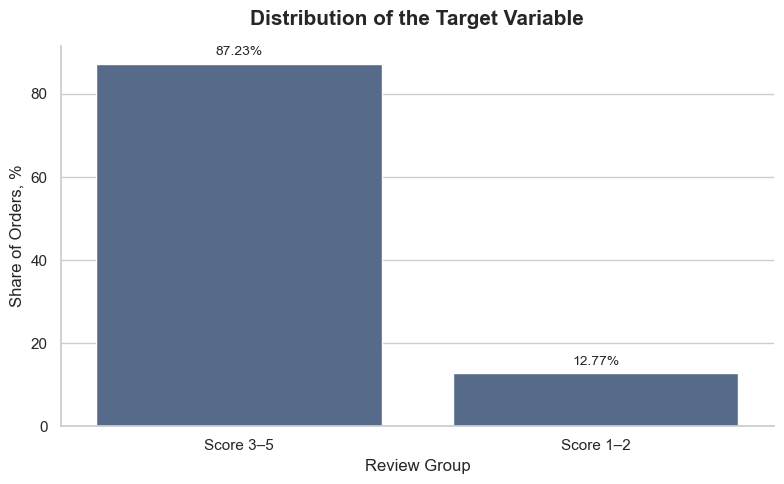

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=target_distribution,
    x="review_group",
    y="orders_share_percent",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Distribution of the Target Variable",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Review Group")
ax.set_ylabel("Share of Orders, %")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontsize=10,
    )

sns.despine()
plt.tight_layout()
plt.show()

### Target Distribution Findings

The target variable is moderately imbalanced.

Approximately **12.77%** of delivered orders received a low review score of 1 or 2, while **87.23%** received a score from 3 to 5.

Because the negative class is much more common, accuracy alone would be misleading. A model that predicts every order as non-low-review would achieve an accuracy of about 87%, despite failing to identify any dissatisfied customers.

Therefore, model evaluation should focus on metrics that reflect performance on the minority class, including recall, precision, F1-score, ROC-AUC, and PR-AUC. The train-test split should also preserve the original target proportions.

## 2. Target and Feature Analysis

In [14]:
numeric_features = [
    "order_value",
    "products_value",
    "freight_value",
    "items_count",
    "payment_value",
    "delivery_time_days",
    "delivery_delay_days",
]

categorical_features = [
    "is_delayed",
    "customer_state",
]

In [15]:
model_data[numeric_features].describe(
    percentiles=[
        0.5,
        0.75,
        0.9,
        0.95,
        0.99,
    ]
)

,order_value,products_value,freight_value,items_count,payment_value,delivery_time_days,delivery_delay_days
count,"95,832.000","95,832.000","95,832.000","95,832.000","95,831.000","95,824.000","95,824.000"
mean,159.564,136.802,22.762,1.141,159.594,12.517,-11.215
std,217.486,207.781,21.522,0.534,217.506,9.461,10.114
min,9.590,0.850,0.000,1.000,9.590,0.533,-146.016
50%,105.280,86.250,17.160,1.000,105.280,10.206,-11.973
75%,176.160,149.900,23.990,1.000,176.160,15.664,-6.407
90%,305.648,269.000,39.320,1.000,305.680,23.031,-1.169
95%,445.409,399.000,54.700,2.000,445.435,29.131,3.727
99%,"1,048.483",990.000,104.111,3.000,"1,048.492",45.853,18.741
max,"13,664.080","13,440.000","1,794.960",21.000,"13,664.080",208.352,188.975


In [16]:
feature_summary = (
    model_data
    .groupby("is_low_review")
    .agg(
        orders_count=("order_id", "count"),
        average_order_value=("order_value", "mean"),
        median_order_value=("order_value", "median"),
        average_freight_value=("freight_value", "mean"),
        average_items_count=("items_count", "mean"),
        average_delivery_time=("delivery_time_days", "mean"),
        median_delivery_time=("delivery_time_days", "median"),
        average_delivery_delay=("delivery_delay_days", "mean"),
        delayed_orders_share=("is_delayed", "mean"),
    )
    .reset_index()
)

feature_summary["review_group"] = (
    feature_summary["is_low_review"]
    .map(
        {
            0: "Score 3–5",
            1: "Score 1–2",
        }
    )
)

feature_summary["delayed_orders_share_percent"] = (
    feature_summary["delayed_orders_share"] * 100
)

feature_summary

,is_low_review,orders_count,average_order_value,median_order_value,average_freight_value,average_items_count,average_delivery_time,median_delivery_time,average_delivery_delay,delayed_orders_share,review_group,delayed_orders_share_percent
0,0,83595,155.415,103.140,22.036,1.116,11.389,9.876,-12.209,0.042,Score 3–5,4.217
1,1,12237,187.908,118.410,27.724,1.317,20.223,15.721,-4.425,0.338,Score 1–2,33.802


### Delivery Delays by Review Group

In [17]:
delay_by_review = (
    model_data
    .groupby("is_low_review")
    .agg(
        delayed_orders_share=(
            "is_delayed",
            "mean",
        )
    )
    .reset_index()
)

delay_by_review["review_group"] = (
    delay_by_review["is_low_review"]
    .map(
        {
            0: "Score 3–5",
            1: "Score 1–2",
        }
    )
)

delay_by_review["delayed_orders_share_percent"] = (
    delay_by_review["delayed_orders_share"] * 100
)

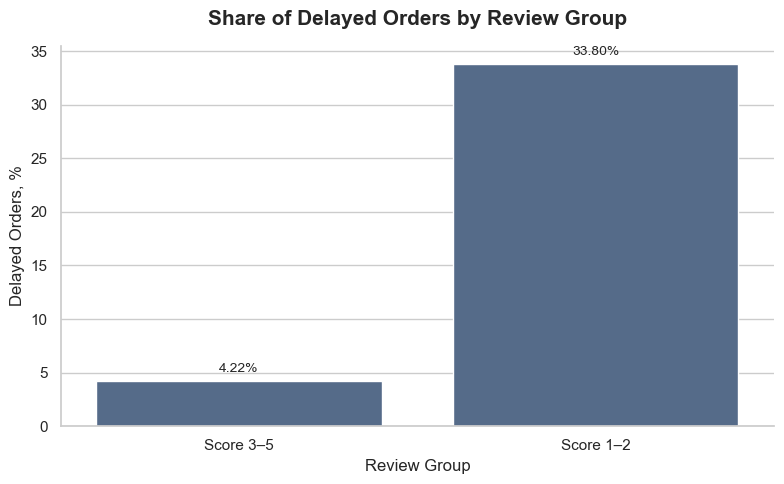

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=delay_by_review,
    x="review_group",
    y="delayed_orders_share_percent",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Share of Delayed Orders by Review Group",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Review Group")
ax.set_ylabel("Delayed Orders, %")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontsize=10,
    )

sns.despine()
plt.tight_layout()
plt.show()

### Delivery Delay Findings

Delivery delays are strongly associated with low customer review scores.

Approximately **33.80%** of orders with scores 1–2 were delivered late, compared with only **4.22%** of orders with scores 3–5. Thus, delayed delivery is much more common among dissatisfied customers.

This suggests that delivery performance will likely be one of the strongest predictors in the model. However, the relationship should not be interpreted as strictly causal, since product quality, seller performance, and other factors may also influence customer reviews.

Because the model uses actual delivery information, it should be interpreted as a post-delivery risk model rather than a model available at the moment of purchase.

## 3. Train and Test Split

In [19]:
feature_columns = (
    numeric_features
    + categorical_features
)

X = model_data[feature_columns].copy()
y = model_data["is_low_review"].copy()

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

In [21]:
split_summary = pd.DataFrame(
    {
        "dataset": [
            "Train",
            "Test",
        ],
        "observations_count": [
            len(X_train),
            len(X_test),
        ],
        "low_review_share_percent": [
            y_train.mean() * 100,
            y_test.mean() * 100,
        ],
    }
)

split_summary

,dataset,observations_count,low_review_share_percent
0,Train,76665,12.770
1,Test,19167,12.767


In [22]:
X_train.index.intersection(
    X_test.index
).size

0

## 4. Preprocessing Pipeline

### Numeric Feature Preprocessing

For numeric features:

- missing values are replaced with the median;
- features are standardized for logistic regression.

### Categorical Feature Preprocessing

For categorical features:

- missing values are replaced with the most frequent value;
- categories are transformed using one-hot encoding;
- previously unseen categories in the test data are ignored.

In [23]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

In [24]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent",
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
    ]
)

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features,
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features,
        ),
    ]
)

preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['order_value', 'products_value',
                                  'freight_value', 'items_count',
                                  'payment_value', 'delivery_time_days',
                                  'delivery_delay_days']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['is_delayed', 'customer_state'])])

## 5. Baseline Model

In [27]:
dummy_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            DummyClassifier(
                strategy="prior",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

dummy_model.fit(
    X_train,
    y_train,
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['order_value',
                                                   'products_value',
                                                   'freight_value',
                                                   'items_count',
                                                   'payment_value',
                                                   'delivery_time_days',
                                                   'delivery_delay_days']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['is_delayed',
                                                   'customer_state'])])),
                ('classifier', DummyClassifier(random_state=42))])

In [28]:
dummy_predictions = dummy_model.predict(X_test)

dummy_probabilities = dummy_model.predict_proba(X_test)[:, 1]

In [29]:
dummy_metrics = pd.DataFrame(
    {
        "model": [
            "Dummy Classifier",
        ],
        "roc_auc": [
            roc_auc_score(
                y_test,
                dummy_probabilities,
            )
        ],
        "pr_auc": [
            average_precision_score(
                y_test,
                dummy_probabilities,
            )
        ],
        "precision": [
            precision_score(
                y_test,
                dummy_predictions,
                zero_division=0,
            )
        ],
        "recall": [
            recall_score(
                y_test,
                dummy_predictions,
                zero_division=0,
            )
        ],
        "f1_score": [
            f1_score(
                y_test,
                dummy_predictions,
                zero_division=0,
            )
        ],
    }
)

dummy_metrics

,model,roc_auc,pr_auc,precision,recall,f1_score
0,Dummy Classifier,0.500,0.128,0.000,0.000,0.000


### Baseline Model Findings

The dummy classifier represents a naive strategy that always predicts the majority class.

Its ROC-AUC is 0.50, indicating no ability to distinguish between low- and high-review orders. PR-AUC is approximately equal to the prevalence of low reviews in the dataset.

The model does not identify any low-review orders, so its precision, recall, and F1-score for the positive class are all zero.

Therefore, the dummy classifier is not useful for the business task. It serves only as a baseline that more advanced models must outperform.

## 6. Logistic Regression

### Model Training

Logistic regression is used as the first interpretable classification model.

Because low-review orders represent only about 13% of observations, balanced class weights are used to assign greater importance to mistakes on the minority class.

In [30]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

In [31]:
logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

In [32]:
logistic_metrics = pd.DataFrame(
    {
        "model": [
            "Logistic Regression",
        ],
        "roc_auc": [
            roc_auc_score(
                y_test,
                logistic_probabilities,
            )
        ],
        "pr_auc": [
            average_precision_score(
                y_test,
                logistic_probabilities,
            )
        ],
        "precision": [
            precision_score(
                y_test,
                logistic_predictions,
                zero_division=0,
            )
        ],
        "recall": [
            recall_score(
                y_test,
                logistic_predictions,
                zero_division=0,
            )
        ],
        "f1_score": [
            f1_score(
                y_test,
                logistic_predictions,
                zero_division=0,
            )
        ],
    }
)

logistic_metrics

,model,roc_auc,pr_auc,precision,recall,f1_score
0,Logistic Regression,0.744,0.405,0.349,0.533,0.422


In [33]:
baseline_logistic_comparison = pd.concat(
    [
        dummy_metrics,
        logistic_metrics,
    ],
    ignore_index=True,
)

baseline_logistic_comparison

,model,roc_auc,pr_auc,precision,recall,f1_score
0,Dummy Classifier,0.500,0.128,0.000,0.000,0.000
1,Logistic Regression,0.744,0.405,0.349,0.533,0.422


In [34]:
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=[
            "Score 3–5",
            "Score 1–2",
        ],
        digits=3,
    )
)

              precision    recall  f1-score   support

   Score 3–5      0.926     0.854     0.889     16720
   Score 1–2      0.349     0.533     0.422      2447

    accuracy                          0.813     19167
   macro avg      0.637     0.694     0.655     19167
weighted avg      0.852     0.813     0.829     19167



### Logistic Regression Findings

Logistic regression substantially outperforms the dummy baseline.

ROC-AUC increased from **0.500** to **0.744**, which indicates that the model has a reasonable ability to rank orders by the risk of receiving a low review.

PR-AUC increased from **0.128** to **0.405**, which is especially important because the positive class is imbalanced. The model therefore performs much better than the baseline at identifying low-review orders.

For the low-review class, recall is **0.533**, meaning that the model identifies approximately 53% of all orders that actually receive a score of 1 or 2.

Precision is **0.349**, meaning that among all orders flagged as high risk, about 35% actually receive a low review.

The F1-score is **0.422**, reflecting a moderate balance between precision and recall.

The model is therefore useful as a first real classifier, but it still produces a substantial number of false positives and misses almost half of the dissatisfied customers. Threshold tuning and a more flexible tree-based model may improve this trade-off.

## 7. Tree-Based Model

### Tree Preprocessing

In [35]:
tree_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
            ),
        ),
    ]
)

tree_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent",
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            tree_numeric_transformer,
            numeric_features,
        ),
        (
            "categorical",
            tree_categorical_transformer,
            categorical_features,
        ),
    ]
)

### Random Forest Training

In [36]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=20,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['order_value',
                                                   'products_value',
                                                   'freight_value',
                                                   'items_count',
                                                   'payment_value',
                                                   'delivery_time_days',
                                                   'delivery_delay_days']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['is_delayed',
                                                   'customer_state'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        min_samples_leaf=20, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [37]:
random_forest_predictions = (
    random_forest_model.predict(X_test)
)

random_forest_probabilities = (
    random_forest_model.predict_proba(X_test)[:, 1]
)

In [38]:
random_forest_metrics = pd.DataFrame(
    {
        "model": [
            "Random Forest",
        ],
        "roc_auc": [
            roc_auc_score(
                y_test,
                random_forest_probabilities,
            )
        ],
        "pr_auc": [
            average_precision_score(
                y_test,
                random_forest_probabilities,
            )
        ],
        "precision": [
            precision_score(
                y_test,
                random_forest_predictions,
                zero_division=0,
            )
        ],
        "recall": [
            recall_score(
                y_test,
                random_forest_predictions,
                zero_division=0,
            )
        ],
        "f1_score": [
            f1_score(
                y_test,
                random_forest_predictions,
                zero_division=0,
            )
        ],
    }
)

random_forest_metrics

,model,roc_auc,pr_auc,precision,recall,f1_score
0,Random Forest,0.745,0.449,0.379,0.520,0.438


In [39]:
model_comparison = pd.concat(
    [
        dummy_metrics,
        logistic_metrics,
        random_forest_metrics,
    ],
    ignore_index=True,
)

model_comparison

,model,roc_auc,pr_auc,precision,recall,f1_score
0,Dummy Classifier,0.500,0.128,0.000,0.000,0.000
1,Logistic Regression,0.744,0.405,0.349,0.533,0.422
2,Random Forest,0.745,0.449,0.379,0.520,0.438


In [40]:
print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=[
            "Score 3–5",
            "Score 1–2",
        ],
        digits=3,
    )
)

              precision    recall  f1-score   support

   Score 3–5      0.926     0.875     0.900     16720
   Score 1–2      0.379     0.520     0.438      2447

    accuracy                          0.830     19167
   macro avg      0.652     0.698     0.669     19167
weighted avg      0.856     0.830     0.841     19167



### Random Forest Findings

Random Forest slightly outperforms Logistic Regression on most metrics.

ROC-AUC increased only marginally, from **0.744** to **0.745**, so both models have almost the same overall ranking ability.

The more noticeable improvement appears in PR-AUC, which increased from **0.405** to **0.449**. This is important for the imbalanced target because PR-AUC focuses more directly on the quality of predictions for low-review orders.

For the low-review class:

- precision increased from **0.349** to **0.379**;
- recall decreased slightly from **0.533** to **0.520**;
- F1-score increased from **0.422** to **0.438**.

Thus, Random Forest produces fewer false-positive alerts and achieves a better balance between precision and recall, although it identifies slightly fewer dissatisfied customers.

Overall, Random Forest is the stronger model at the default threshold, but the improvement over Logistic Regression is moderate rather than dramatic.

## 8. Model Comparison

In [41]:
dummy_fpr, dummy_tpr, _ = roc_curve(
    y_test,
    dummy_probabilities,
)

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities,
)

forest_fpr, forest_tpr, _ = roc_curve(
    y_test,
    random_forest_probabilities,
)

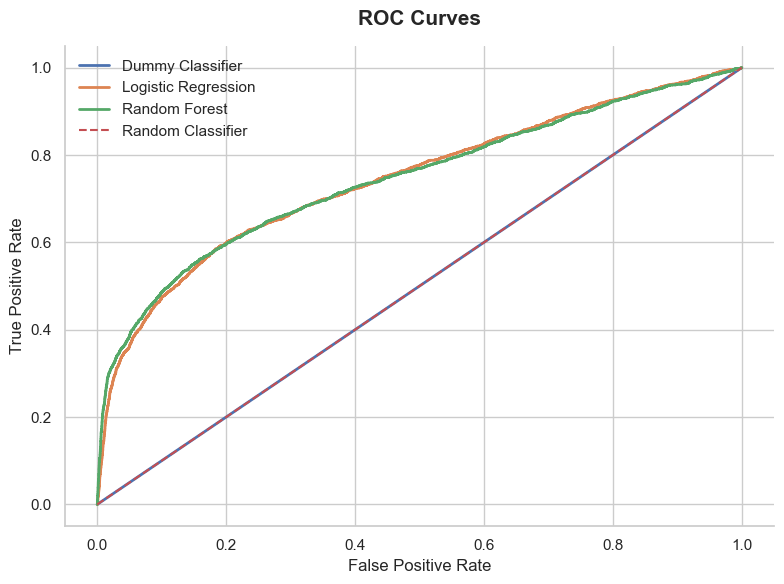

In [42]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    dummy_fpr,
    dummy_tpr,
    label="Dummy Classifier",
    linewidth=2,
)

ax.plot(
    logistic_fpr,
    logistic_tpr,
    label="Logistic Regression",
    linewidth=2,
)

ax.plot(
    forest_fpr,
    forest_tpr,
    label="Random Forest",
    linewidth=2,
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier",
)

ax.set_title(
    "ROC Curves",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.legend(
    frameon=False,
)

sns.despine()
plt.tight_layout()
plt.show()

In [43]:
dummy_precision_curve, dummy_recall_curve, _ = (
    precision_recall_curve(
        y_test,
        dummy_probabilities,
    )
)

logistic_precision_curve, logistic_recall_curve, _ = (
    precision_recall_curve(
        y_test,
        logistic_probabilities,
    )
)

forest_precision_curve, forest_recall_curve, _ = (
    precision_recall_curve(
        y_test,
        random_forest_probabilities,
    )
)

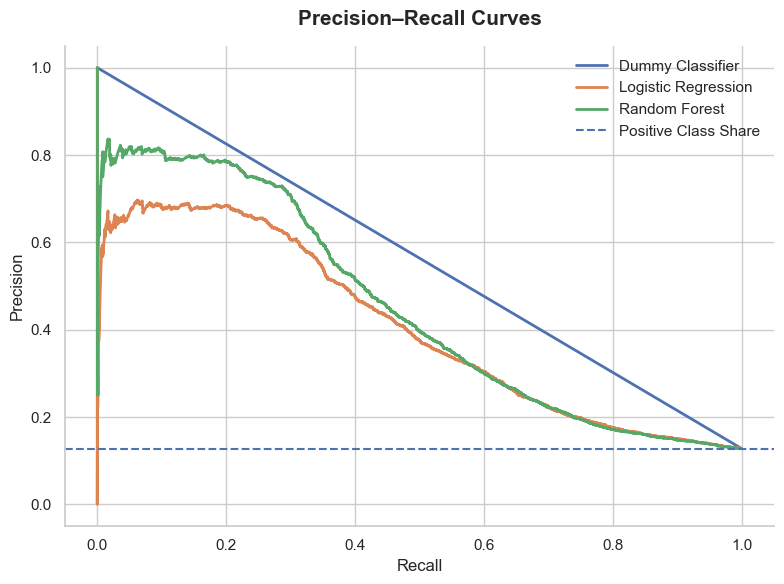

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    dummy_recall_curve,
    dummy_precision_curve,
    label="Dummy Classifier",
    linewidth=2,
)

ax.plot(
    logistic_recall_curve,
    logistic_precision_curve,
    label="Logistic Regression",
    linewidth=2,
)

ax.plot(
    forest_recall_curve,
    forest_precision_curve,
    label="Random Forest",
    linewidth=2,
)

ax.axhline(
    y=y_test.mean(),
    linestyle="--",
    linewidth=1.5,
    label="Positive Class Share",
)

ax.set_title(
    "Precision–Recall Curves",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.legend(
    frameon=False,
)

sns.despine()
plt.tight_layout()
plt.show()

### Model Comparison Findings

Both Logistic Regression and Random Forest clearly outperform the dummy baseline.

The ROC curves of the two trained models are very similar, which is consistent with their nearly identical ROC-AUC values of approximately 0.74. This means that both models have comparable overall ability to rank low-review orders above non-low-review orders.

The Precision–Recall curve provides a more informative comparison because low-review orders represent only about 13% of the dataset. Random Forest generally maintains higher precision than Logistic Regression across a substantial range of recall values, which is consistent with its higher PR-AUC of 0.449 compared with 0.405.

Therefore, Random Forest is selected as the primary model for further analysis. However, Logistic Regression remains a useful interpretable benchmark.

## 9. Threshold Selection

### Business Objective

The model is intended to identify customers at risk of dissatisfaction so that the company can take preventive action.

Missing a genuinely dissatisfied customer may be more costly than sending an unnecessary intervention to a customer who would otherwise leave a positive review.

Therefore, recall is important, but the selected threshold should still preserve an acceptable level of precision.

In [47]:
forest_precision_values, forest_recall_values, forest_thresholds = (
    precision_recall_curve(
        y_test,
        random_forest_probabilities,
    )
)

In [48]:
threshold_metrics = pd.DataFrame(
    {
        "threshold": forest_thresholds,
        "precision": forest_precision_values[:-1],
        "recall": forest_recall_values[:-1],
    }
)

In [49]:
threshold_metrics["f1_score"] = (
    2 * threshold_metrics["precision"]
    * threshold_metrics["recall"]
    / (
        threshold_metrics["precision"]
        + threshold_metrics["recall"]
    )
)

threshold_metrics = threshold_metrics.replace(
    [np.inf, -np.inf], np.nan,
).dropna()

threshold_metrics.head()

,threshold,precision,recall,f1_score
0,0.237,0.128,1.000,0.226
1,0.241,0.128,1.000,0.226
2,0.242,0.128,1.000,0.226
3,0.243,0.128,1.000,0.226
4,0.247,0.128,1.000,0.226


In [50]:
best_f1_row = threshold_metrics.loc[
    threshold_metrics["f1_score"].idxmax()
]

best_f1_row

threshold   0.609
precision   0.462
recall      0.444
f1_score    0.453
Name: 16808, dtype: float64

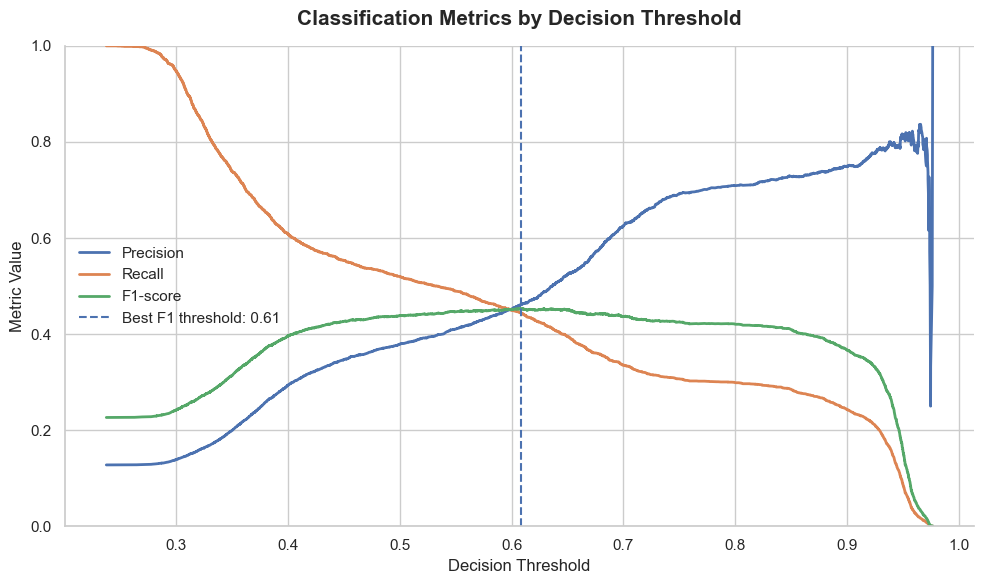

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    threshold_metrics["threshold"],
    threshold_metrics["precision"],
    label="Precision",
    linewidth=2,
)

ax.plot(
    threshold_metrics["threshold"],
    threshold_metrics["recall"],
    label="Recall",
    linewidth=2,
)

ax.plot(
    threshold_metrics["threshold"],
    threshold_metrics["f1_score"],
    label="F1-score",
    linewidth=2,
)

ax.axvline(
    x=best_f1_row["threshold"],
    linestyle="--",
    linewidth=1.5,
    label=(
        "Best F1 threshold: "
        f"{best_f1_row['threshold']:.2f}"
    ),
)

ax.set_title(
    "Classification Metrics by Decision Threshold",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Metric Value")
ax.set_ylim(0, 1)

ax.legend(
    frameon=False,
)

sns.despine()
plt.tight_layout()
plt.show()

### Threshold Selection Findings

The default threshold of 0.50 is not optimal for the Random Forest model.

The maximum F1-score is achieved at a threshold of approximately **0.61**. At this point, precision and recall are both close to **0.45**, which provides the best overall balance between false-positive alerts and missed low-review orders.

Increasing the threshold above 0.61 improves precision but reduces recall, meaning that fewer customers are flagged while more genuinely dissatisfied customers are missed.

Lowering the threshold improves recall but produces more false-positive alerts.

For this notebook, the threshold of **0.61** is selected because it maximizes F1-score. In a real product setting, the threshold should instead be chosen based on the relative business costs of false positives and false negatives.

### Predictions at the Selected Threshold

In [52]:
selected_threshold = float(
    best_f1_row["threshold"]
)

selected_threshold

0.6086595706647123

In [53]:
forest_predictions_selected = (
    random_forest_probabilities
    >= selected_threshold
).astype(int)

In [54]:
selected_threshold_metrics = pd.DataFrame(
    {
        "metric": [
            "Threshold",
            "Precision",
            "Recall",
            "F1-score",
        ],
        "value": [
            selected_threshold,
            precision_score(
                y_test,
                forest_predictions_selected,
                zero_division=0,
            ),
            recall_score(
                y_test,
                forest_predictions_selected,
                zero_division=0,
            ),
            f1_score(
                y_test,
                forest_predictions_selected,
                zero_division=0,
            ),
        ],
    }
)

selected_threshold_metrics

,metric,value
0,Threshold,0.609
1,Precision,0.462
2,Recall,0.444
3,F1-score,0.453


### Confusion Matrix

In [55]:
selected_confusion_matrix = confusion_matrix(
    y_test,
    forest_predictions_selected,
)

selected_confusion_matrix

array([[15455,  1265],
       [ 1360,  1087]])

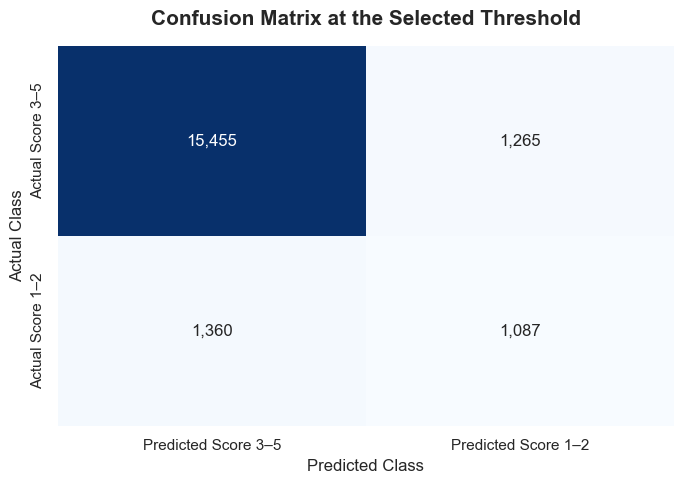

In [56]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    selected_confusion_matrix,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Predicted Score 3–5",
        "Predicted Score 1–2",
    ],
    yticklabels=[
        "Actual Score 3–5",
        "Actual Score 1–2",
    ],
    ax=ax,
)

ax.set_title(
    "Confusion Matrix at the Selected Threshold",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

### Selected Threshold Findings

At the selected threshold of approximately **0.609**, the Random Forest model achieves:

- precision of **0.462**;
- recall of **0.444**;
- F1-score of **0.453**.

The confusion matrix shows that the model correctly identifies **1,087** low-review orders, while **1,360** low-review orders are missed.

At the same time, **1,265** orders are incorrectly flagged as high risk, while **15,455** non-low-review orders are correctly classified.

Compared with the default threshold of 0.50, the selected threshold improves precision and F1-score but reduces recall. The model therefore sends fewer false alerts, but it also misses more dissatisfied customers.

The selected threshold provides the best balance according to F1-score. However, if the business cost of missing a dissatisfied customer is higher than the cost of an unnecessary intervention, a lower threshold may be preferable.

## 10. Feature Importance

In [57]:
fitted_preprocessor = (
    random_forest_model.named_steps[
        "preprocessor"
    ]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

In [58]:
feature_importances = (
    random_forest_model.named_steps[
        "classifier"
    ].feature_importances_
)

feature_importance = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": feature_importances,
    }
).sort_values(
    "importance",
    ascending=False,
)

feature_importance.head(15)

,feature,importance
6,numeric__delivery_delay_days,0.260
5,numeric__delivery_time_days,0.150
8,categorical__is_delayed_True,0.148
7,categorical__is_delayed_False,0.147
3,numeric__items_count,0.120
2,numeric__freight_value,0.063
0,numeric__order_value,0.032
4,numeric__payment_value,0.030
1,numeric__products_value,0.026
28,categorical__customer_state_RJ,0.006


In [59]:
feature_importance["feature"] = (
    feature_importance["feature"]
    .str.replace(
        "numeric__",
        "",
        regex=False,
    )
    .str.replace(
        "categorical__",
        "",
        regex=False,
    )
)

In [60]:
top_feature_importance = (
    feature_importance
    .head(15)
    .sort_values(
        "importance",
        ascending=True,
    )
)

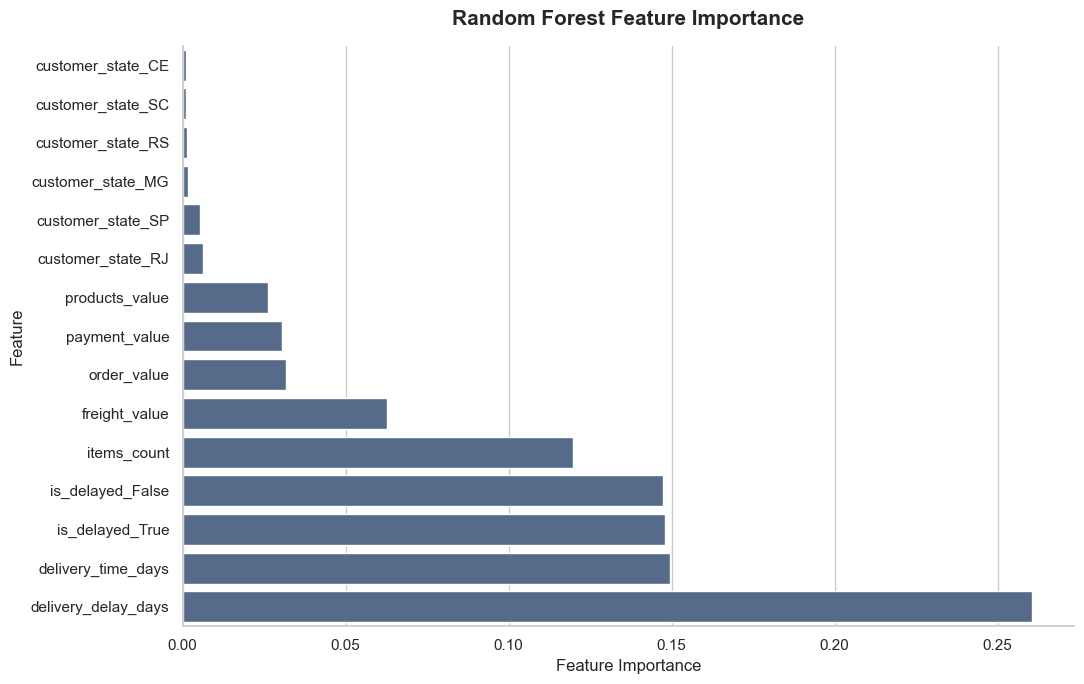

In [61]:
fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(
    data=top_feature_importance,
    x="importance",
    y="feature",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Random Forest Feature Importance",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")

sns.despine()
plt.tight_layout()
plt.show()

### Feature Importance Findings

Delivery-related variables dominate the Random Forest model.

`delivery_delay_days` is the most important feature, followed by `delivery_time_days` and the indicators showing whether an order was delayed. This is consistent with the earlier statistical analysis, where delayed deliveries were strongly associated with low review scores.

`items_count` and `freight_value` also contribute to the predictions, while order value, payment value, product value, and customer state appear less influential.

The separate features `is_delayed_True` and `is_delayed_False` are created by one-hot encoding the binary variable. Together, they represent the same underlying characteristic: whether the order was delivered late.

These importances describe how often and how effectively the Random Forest uses each feature for splitting observations. They do not show the direction of the relationship and should not be interpreted as causal effects.

### Permutation Feature Importance

In [63]:
permutation_result = permutation_importance(
    random_forest_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

In [64]:
permutation_importance_df = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": (
            permutation_result.importances_mean
        ),
        "importance_std": (
            permutation_result.importances_std
        ),
    }
).sort_values(
    "importance_mean",
    ascending=False,
)

permutation_importance_df

,feature,importance_mean,importance_std
6,delivery_delay_days,0.161,0.003
7,is_delayed,0.058,0.004
3,items_count,0.048,0.001
5,delivery_time_days,0.027,0.004
8,customer_state,0.005,0.002
2,freight_value,0.004,0.002
4,payment_value,-0.001,0.002
1,products_value,-0.001,0.002
0,order_value,-0.002,0.002


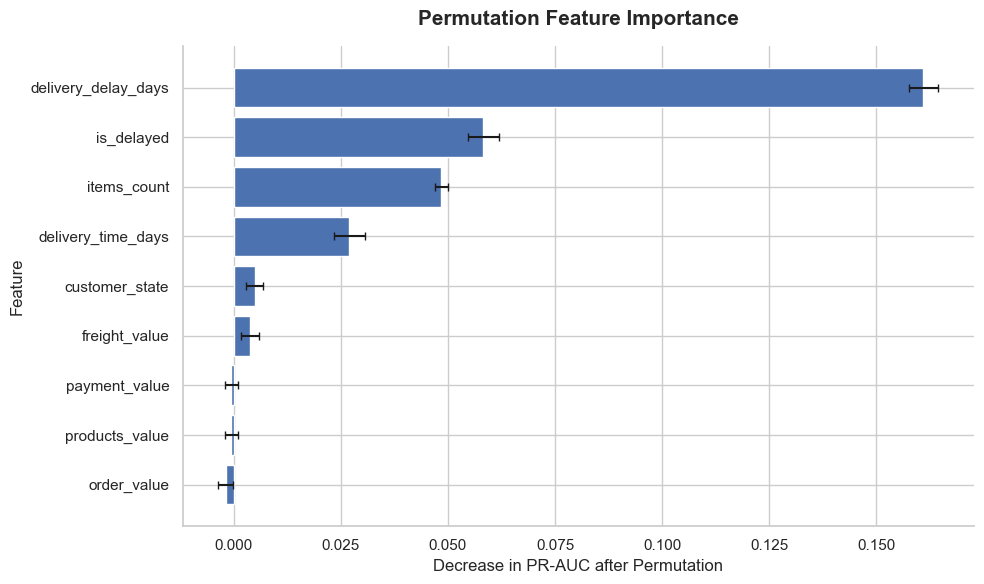

Exception ignored in: <function ResourceTracker.__del__ at 0x11b169bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10403dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10a93dbc0>
Traceback (most recent call last

In [65]:
plot_data = (
    permutation_importance_df
    .sort_values(
        "importance_mean",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_data["feature"],
    plot_data["importance_mean"],
    xerr=plot_data["importance_std"],
    capsize=3,
)

ax.set_title(
    "Permutation Feature Importance",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Decrease in PR-AUC after Permutation")
ax.set_ylabel("Feature")

sns.despine()
plt.tight_layout()
plt.show()

### Permutation Importance Findings

Permutation importance confirms that delivery performance is the main source of predictive signal in the model.

`delivery_delay_days` is the most important feature: randomly shuffling it produces the largest decrease in PR-AUC. The binary indicator `is_delayed` is the second most important feature, followed by `items_count` and `delivery_time_days`.

Customer state and freight value provide only a small additional contribution. Payment value, product value, and total order value have almost no independent predictive value after the other features are taken into account.

Some features have importance values close to zero or slightly below zero. A negative value does not mean that the feature has a meaningful negative effect on review scores. It means that randomly shuffling the feature did not reduce test performance and may have produced a very small improvement because of random variation or redundant information.

Overall, the permutation results support the earlier conclusion: delivery delays are the strongest available indicators of low customer satisfaction.

## 11. Error Analysis

### Prediction Results

Error analysis helps identify the types of orders the model classifies incorrectly.

The analysis uses predictions produced at the selected threshold of approximately 0.609.

In [66]:
error_analysis = X_test.copy()

error_analysis["actual_class"] = (y_test.values)

error_analysis["predicted_probability"] = (random_forest_probabilities)

error_analysis["predicted_class"] = (forest_predictions_selected)

In [67]:
conditions = [
    (
        (error_analysis["actual_class"] == 0)
        & (error_analysis["predicted_class"] == 0)
    ),
    (
        (error_analysis["actual_class"] == 0)
        & (error_analysis["predicted_class"] == 1)
    ),
    (
        (error_analysis["actual_class"] == 1)
        & (error_analysis["predicted_class"] == 0)
    ),
    (
        (error_analysis["actual_class"] == 1)
        & (error_analysis["predicted_class"] == 1)
    ),
]

result_labels = [
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive",
]

error_analysis["prediction_result"] = np.select(
    conditions,
    result_labels,
    default="Unknown",
)

In [68]:
prediction_result_summary = (
    error_analysis["prediction_result"]
    .value_counts()
    .rename_axis("prediction_result")
    .reset_index(name="orders_count")
)

prediction_result_summary

,prediction_result,orders_count
0,True Negative,15455
1,False Negative,1360
2,False Positive,1265
3,True Positive,1087


In [69]:
error_group_summary = (
    error_analysis
    .groupby("prediction_result")
    .agg(
        orders_count=(
            "predicted_class",
            "count",
        ),
        average_predicted_probability=(
            "predicted_probability",
            "mean",
        ),
        average_delivery_delay=(
            "delivery_delay_days",
            "mean",
        ),
        average_delivery_time=(
            "delivery_time_days",
            "mean",
        ),
        delayed_orders_share=(
            "is_delayed",
            "mean",
        ),
        average_items_count=(
            "items_count",
            "mean",
        ),
        average_order_value=(
            "order_value",
            "mean",
        ),
    )
    .reset_index()
)

error_group_summary["delayed_orders_share_percent"] = (
    error_group_summary["delayed_orders_share"]
    * 100
)

error_group_summary

,prediction_result,orders_count,average_predicted_probability,average_delivery_delay,average_delivery_time,delayed_orders_share,average_items_count,average_order_value,delayed_orders_share_percent
0,False Negative,1360,0.382,-12.049,12.506,0.024,1.131,156.075,2.353
1,False Positive,1265,0.725,-6.565,19.103,0.343,2.023,254.144,34.308
2,True Negative,15455,0.353,-12.679,10.749,0.018,1.049,149.677,1.793
3,True Positive,1087,0.845,4.916,30.075,0.718,1.553,221.533,71.849


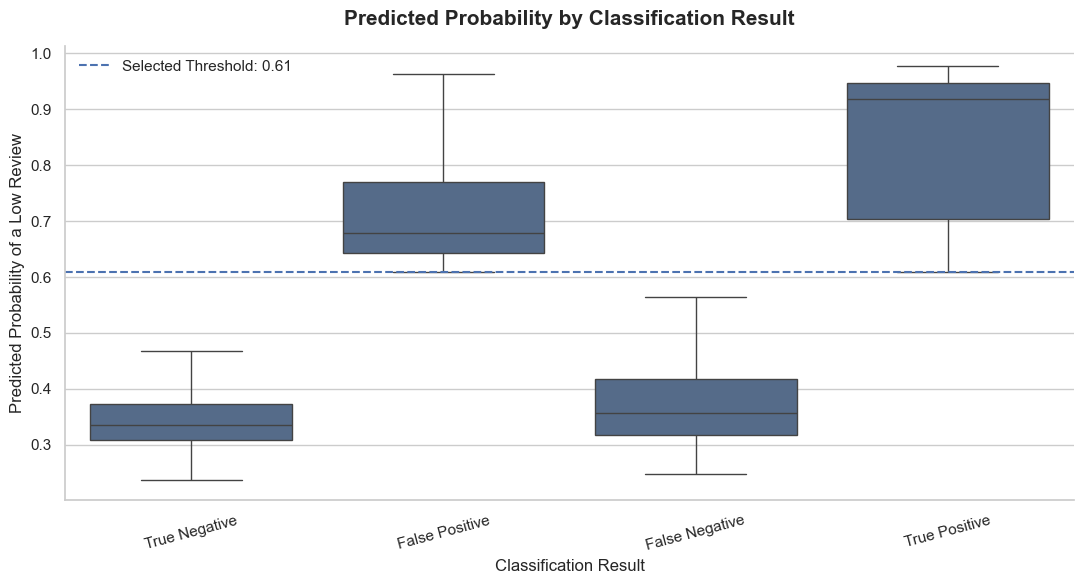

In [70]:
result_order = [
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive",
]

fig, ax = plt.subplots(figsize=(11, 6))

sns.boxplot(
    data=error_analysis,
    x="prediction_result",
    y="predicted_probability",
    order=result_order,
    showfliers=False,
    color="#4C6A92",
    ax=ax,
)

ax.axhline(
    y=selected_threshold,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Selected Threshold: "
        f"{selected_threshold:.2f}"
    ),
)

ax.set_title(
    "Predicted Probability by Classification Result",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Classification Result")
ax.set_ylabel("Predicted Probability of a Low Review")

ax.tick_params(
    axis="x",
    rotation=15,
)

ax.legend(
    frameon=False,
)

sns.despine()
plt.tight_layout()
plt.show()

### Error Analysis Findings

The predicted probability distributions differ clearly across the four classification outcomes.

`True Negative` orders generally receive low predicted probabilities, which means that the model is confident when identifying orders unlikely to receive a low review.

`True Positive` orders have the highest predicted probabilities, with most values substantially above the selected threshold. These are the low-review orders that the model identifies most confidently.

`False Positive` orders are assigned probabilities above the threshold even though they ultimately receive scores from 3 to 5. Their probabilities are generally lower than those of true positives, which suggests that many false alerts are borderline cases rather than highly confident mistakes.

`False Negative` orders receive probabilities below the threshold despite ultimately receiving a low review. Their probability distribution is similar to that of true negatives, indicating that the available features do not provide enough signal to distinguish these dissatisfied customers.

Overall, the model performs best when low reviews are strongly associated with delivery problems. It is more likely to miss low reviews caused by factors not represented in the dataset, such as product quality, inaccurate descriptions, packaging damage, seller communication, or customer expectations.

## 12. Key Findings

### Model Performance

1. Low-review orders represent approximately 12.8% of delivered orders, making the target moderately imbalanced.

2. The dummy classifier cannot identify any low-review orders and serves only as a minimum performance baseline.

3. Logistic Regression substantially outperforms the dummy baseline, achieving:
   - ROC-AUC of approximately 0.744;
   - PR-AUC of approximately 0.405;
   - recall of approximately 0.533;
   - F1-score of approximately 0.422.

4. Random Forest performs slightly better than Logistic Regression, with:
   - ROC-AUC of approximately 0.745;
   - PR-AUC of approximately 0.449;
   - precision of approximately 0.379;
   - recall of approximately 0.520;
   - F1-score of approximately 0.438.

5. Random Forest is selected as the primary model because it achieves the strongest PR-AUC and F1-score.

### Threshold Selection

6. The default probability threshold of 0.50 is not optimal for the selected model.

7. A threshold of approximately 0.609 maximizes F1-score and produces:
   - precision of approximately 0.462;
   - recall of approximately 0.444;
   - F1-score of approximately 0.453.

8. At this threshold, the model correctly identifies 1,087 low-review orders but misses 1,360.

9. The final threshold should depend on business costs. A lower threshold would identify more dissatisfied customers but would also create more false-positive interventions.

### Main Predictive Factors

10. Delivery performance provides the strongest predictive signal.

11. `delivery_delay_days`, `is_delayed`, and `delivery_time_days` are among the most important features.

12. `items_count` also provides meaningful predictive information, while payment and order value variables contribute relatively little after delivery variables are included.

13. Permutation importance confirms that delivery delay is the strongest independent predictor of low review risk.

### Business Interpretation

14. The model can be used after delivery to identify customers at elevated risk of dissatisfaction.

15. Potential interventions include proactive support, compensation, follow-up communication, or requesting additional feedback.

16. The model should not be interpreted as a causal model. Its predictions describe statistical patterns rather than proving that individual features directly cause low reviews.

### Limitations

- The model uses actual delivery information and therefore cannot be applied at the moment an order is placed.
- The dataset does not contain several important sources of customer dissatisfaction, including product quality, packaging condition, seller communication, and whether the product matched its description.
- Delivery-related features are strongly correlated and may share predictive importance.
- Random Forest feature importance does not indicate the direction or causal effect of a feature.
- The model was evaluated using a single train-test split rather than cross-validation.
- The selected threshold maximizes F1-score but does not explicitly incorporate financial costs of false positives and false negatives.
- Model performance and probability calibration should be monitored before real production use.

In [71]:
engine.dispose()